# 🚀 Wildfire Prediction - Phase 3: Multi-Date Processing & Modeling

## What We'll Build

**Phase 2 (Completed ✅)**: Single date feature extraction

**Phase 3 (This Notebook)**:
- Process multiple dates (7-150 days)
- Create temporal features (lags, rolling windows)
- Train gradient boosting model
- Evaluate with proper metrics

---

## Timeline

**Part A**: Multi-date data collection (repeat Phase 2 for each date)
**Part B**: Create temporal features
**Part C**: Train model
**Part D**: Evaluate results

---
## Part A: Setup & Multi-Date Processing

In [1]:
# Libraries
import ee
import pandas as pd
import numpy as np
import geopandas as gpd
from datetime import datetime, timedelta
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import glob
import os

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, auc, average_precision_score
)
import lightgbm as lgb

# Initialize Earth Engine
ee.Initialize(project='wildfire-prediction-ml-project')
print("✅ Libraries loaded")

# Plotting config
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

/home/krithi/Desktop/wildfire-prediction/files/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


✅ Libraries loaded


### Load Static Data (Grid & Topography)

In [2]:
# Load grid
grid_gdf = gpd.read_parquet('../data/grid_10km.parquet')
print(f"✅ Grid loaded: {len(grid_gdf)} cells")

# Load and process topography
topo_df = pd.read_csv('../data/topography_static.csv')
topo_df = topo_df.drop(columns=['system:index', '.geo'], errors='ignore')
topo_df = topo_df.rename(columns={
    'elevation': 'elevation_m',
    'slope': 'slope_deg',
    'aspect': 'aspect_deg'
})

# Cyclical encoding for aspect
topo_df['aspect_sin'] = np.sin(np.radians(topo_df['aspect_deg']))
topo_df['aspect_cos'] = np.cos(np.radians(topo_df['aspect_deg']))

print(f"✅ Topography loaded: {len(topo_df)} cells")

# California bbox
CA_BBOX = [-124.5, 32.5, -114.0, 42.0]

✅ Grid loaded: 12402 cells
✅ Topography loaded: 10539 cells


### 🧠 **Strategy: Load Pre-Exported Multi-Date Data**

Since you've already learned how to export data in Phase 2, for this phase we'll assume you've:

1. Exported weather for multiple dates → `data/multi_date/weather_YYYY_MM_DD.csv`
2. Exported NDVI for multiple dates → `data/multi_date/ndvi_YYYY_MM_DD.csv`
3. Files are already downloaded and saved locally

**If you haven't done this yet**: Go back and run the export code from Phase 2 for each date you want (7-30 dates).

---
## Step 1: Load Multi-Date Weather Data

In [3]:
# Create directory if needed
os.makedirs('../data/multi_date', exist_ok=True)

# Find all weather files
weather_files = sorted(glob.glob('../data/multi_date/weather_*.csv'))

print(f"Found {len(weather_files)} weather files")

if len(weather_files) == 0:
    print("\n⚠️  No weather files found!")
    print("\nPlease export weather data for multiple dates first.")
    print("Use the export code from Phase 2 for each date.")
    print("\nExample dates to try: 2020-08-18 to 2020-08-24 (7 days)")
else:
    print("\nFiles found:")
    for f in weather_files[:5]:  # Show first 5
        print(f"  {os.path.basename(f)}")
    if len(weather_files) > 5:
        print(f"  ... and {len(weather_files) - 5} more")

Found 31 weather files

Files found:
  weather_2020_08_01.csv
  weather_2020_08_02.csv
  weather_2020_08_03.csv
  weather_2020_08_04.csv
  weather_2020_08_05.csv
  ... and 26 more


In [4]:
# Load and process all weather files
all_weather = []

for file in tqdm(weather_files, desc="Loading weather"):
    # Extract date from filename: weather_2020_08_20.csv
    filename = os.path.basename(file)
    date_parts = filename.replace('weather_', '').replace('.csv', '').split('_')
    date_str = f"{date_parts[0]}-{date_parts[1]}-{date_parts[2]}"
    
    # Load
    df = pd.read_csv(file)
    
    # Clean
    df = df.drop(columns=['system:index', '.geo'], errors='ignore')
    
    # Rename columns (same as Phase 2)
    df = df.rename(columns={
        'temp_mean': 'temp_mean_K',
        'temp_max': 'temp_max_K',
        'dewpoint': 'dewpoint_K',
        'wind_speed': 'wind_speed_ms',
        'precip': 'precip_m'
    })
    
    # Convert units
    df['temp_mean_C'] = df['temp_mean_K'] - 273.15
    df['temp_max_C'] = df['temp_max_K'] - 273.15
    df['dewpoint_C'] = df['dewpoint_K'] - 273.15
    df['temp_dewpoint_diff'] = df['temp_mean_C'] - df['dewpoint_C']
    df['precip_mm'] = df['precip_m'] * 1000
    
    # Add date
    df['date'] = date_str
    
    all_weather.append(df)

# Combine
weather_multi = pd.concat(all_weather, ignore_index=True)

print(f"\n✅ Weather data combined: {len(weather_multi):,} records")
print(f"   Date range: {weather_multi['date'].min()} to {weather_multi['date'].max()}")
print(f"   Unique dates: {weather_multi['date'].nunique()}")
print(f"   Unique cells: {weather_multi['cell_id'].nunique()}")

Loading weather: 100%|██████████████████████████| 31/31 [00:00<00:00, 41.83it/s]



✅ Weather data combined: 283,247 records
   Date range: 2020-08-01 to 2020-08-31
   Unique dates: 31
   Unique cells: 9137


---
## Step 2: Load Multi-Date NDVI Data

In [5]:
# Find NDVI files
ndvi_files = sorted(glob.glob('../data/multi_date/ndvi_*.csv'))

print(f"Found {len(ndvi_files)} NDVI files")

# Load and process
all_ndvi = []

for file in tqdm(ndvi_files, desc="Loading NDVI"):
    filename = os.path.basename(file)
    date_parts = filename.replace('ndvi_', '').replace('.csv', '').split('_')
    date_str = f"{date_parts[0]}-{date_parts[1]}-{date_parts[2]}"
    
    df = pd.read_csv(file)
    df = df.drop(columns=['system:index', '.geo'], errors='ignore')
    df['date'] = date_str
    
    all_ndvi.append(df)

ndvi_multi = pd.concat(all_ndvi, ignore_index=True)

print(f"\n✅ NDVI data combined: {len(ndvi_multi):,} records")
print(f"   Date range: {ndvi_multi['date'].min()} to {ndvi_multi['date'].max()}")

Found 31 NDVI files


Loading NDVI: 100%|█████████████████████████████| 31/31 [00:00<00:00, 74.25it/s]


✅ NDVI data combined: 283,048 records
   Date range: 2020-08-01 to 2020-08-31


---
## Step 3: Extract Fires for All Dates

We'll extract fires directly from Earth Engine for each date.

In [10]:
def extract_fires_for_date(date_str, grid_gdf, bbox):
    """
    Extract fire detections and match to grid cells.
    Returns: DataFrame with cell_id, fire_count, fire
    """
    try:
        # Query MODIS fires
        fire_img = ee.ImageCollection('MODIS/061/MOD14A1') \
            .filterDate(date_str, ee.Date(date_str).advance(1, 'day')) \
            .filterBounds(ee.Geometry.Rectangle(bbox)) \
            .select('FireMask') \
            .first()
        
        # Mask to keep only fires (FireMask >= 7)
        fire_only = fire_img.updateMask(fire_img.gte(7))
        
        # Sample fire pixels
        fire_points = fire_only.sample(
            region=ee.Geometry.Rectangle(bbox),
            scale=1000,
            geometries=True
        )
        
        # Download
        fires_data = fire_points.getInfo()
        
        if len(fires_data['features']) == 0:
            return pd.DataFrame(columns=['cell_id', 'fire_count', 'fire'])
        
        # Convert to DataFrame
        fire_records = []
        for feature in fires_data['features']:
            coords = feature['geometry']['coordinates']
            fire_records.append({
                'lon': coords[0],
                'lat': coords[1],
                'fire_mask': feature['properties']['FireMask']
            })
        
        fires_df = pd.DataFrame(fire_records)
        
        # Convert to GeoDataFrame
        fires_gdf = gpd.GeoDataFrame(
            fires_df,
            geometry=[Point(lon, lat) for lon, lat in zip(fires_df['lon'], fires_df['lat'])],
            crs='EPSG:4326'
        )
        
        # Spatial join to grid
        fires_with_cells = gpd.sjoin(fires_gdf, grid_gdf, how='left', predicate='within')
        fires_with_cells = fires_with_cells[fires_with_cells['cell_id'].notna()]
        
        # Count fires per cell
        fire_counts = fires_with_cells.groupby('cell_id').size().reset_index(name='fire_count')
        fire_counts['fire'] = 1
        
        return fire_counts
        
    except Exception as e:
        print(f"   Error for {date_str}: {e}")
        return pd.DataFrame(columns=['cell_id', 'fire_count', 'fire'])

print("✅ Fire extraction function defined")

✅ Fire extraction function defined


In [11]:
# Get unique dates from weather data
dates_to_process = sorted(weather_multi['date'].unique())

print(f"Extracting fires for {len(dates_to_process)} dates...")

# Extract fires for each date
all_fires = []

for date_str in tqdm(dates_to_process, desc="Extracting fires"):
    fire_counts = extract_fires_for_date(date_str, grid_gdf, CA_BBOX)
    
    if len(fire_counts) > 0:
        fire_counts['date'] = date_str
        all_fires.append(fire_counts)
        print(f"   {date_str}: {len(fire_counts)} cells with fires")
    else:
        print(f"   {date_str}: No fires detected")

# Combine
if len(all_fires) > 0:
    fires_multi = pd.concat(all_fires, ignore_index=True)
    print(f"\n✅ Total fires: {fires_multi['fire_count'].sum()} detections")
    print(f"   Affected cells: {len(fires_multi)}")
else:
    fires_multi = pd.DataFrame(columns=['cell_id', 'date', 'fire', 'fire_count'])
    print(f"\n⚠️  No fires detected in this period")

Extracting fires for 31 dates...


Extracting fires:   3%|▊                         | 1/31 [00:07<03:36,  7.21s/it]

   2020-08-01: 6 cells with fires


Extracting fires:   6%|█▋                        | 2/31 [00:11<02:42,  5.62s/it]

   2020-08-02: 13 cells with fires


...

   2020-08-29: 57 cells with fires


Extracting fires:  97%|████████████████████████▏| 30/31 [02:38<00:05,  5.90s/it]

   2020-08-30: 52 cells with fires


Extracting fires: 100%|█████████████████████████| 31/31 [02:38<00:00,  5.13s/it]

   2020-08-31: 54 cells with fires

✅ Total fires: 12185 detections
   Affected cells: 1319


---
## Step 4: Merge All Features

In [12]:
# Start with weather (has cell_id and date)
features = weather_multi.copy()

# Add NDVI
features = features.merge(
    ndvi_multi[['cell_id', 'date', 'ndvi']],
    on=['cell_id', 'date'],
    how='left'
)

# Add topography (static)
features = features.merge(
    topo_df[['cell_id', 'elevation_m', 'slope_deg', 'aspect_sin', 'aspect_cos']],
    on='cell_id',
    how='left'
)

# Add fires
if len(fires_multi) > 0:
    features = features.merge(
        fires_multi[['cell_id', 'date', 'fire']],
        on=['cell_id', 'date'],
        how='left'
    )
else:
    features['fire'] = 0

# Fill NaN fires with 0
features['fire'] = features['fire'].fillna(0).astype(int)

# Convert date to datetime
features['date'] = pd.to_datetime(features['date'])

print(f"\n✅ Features merged: {len(features):,} records")
print(f"\nDataset info:")
print(f"   Shape: {features.shape}")
print(f"   Dates: {features['date'].min()} to {features['date'].max()}")
print(f"   Days: {features['date'].nunique()}")
print(f"   Cells: {features['cell_id'].nunique()}")
print(f"\nFire statistics:")
print(f"   Total fires: {features['fire'].sum()}")
print(f"   Fire rate: {features['fire'].mean()*100:.3f}%")


✅ Features merged: 283,247 records

Dataset info:
   Shape: (283247, 18)
   Dates: 2020-08-01 00:00:00 to 2020-08-31 00:00:00
   Days: 31
   Cells: 9137

Fire statistics:
   Total fires: 1268
   Fire rate: 0.448%


---
## Part B: Create Temporal Features

Now that we have multiple dates, we can create lag and rolling features!
(Changed for 7 day to 1 day, change it back to 7 or more when more data added)

### Add Time Features (Day of Year, Month)

In [13]:
# Extract time components
features['day_of_year'] = features['date'].dt.dayofyear
features['month'] = features['date'].dt.month
features['day_of_week'] = features['date'].dt.dayofweek

# Cyclical encoding
features['doy_sin'] = np.sin(2 * np.pi * features['day_of_year'] / 365)
features['doy_cos'] = np.cos(2 * np.pi * features['day_of_year'] / 365)
features['month_sin'] = np.sin(2 * np.pi * features['month'] / 12)
features['month_cos'] = np.cos(2 * np.pi * features['month'] / 12)

print("✅ Time features created")

✅ Time features created


### Create Lag Features

**Critical**: Sort by cell_id and date first!

In [29]:
# Temperature lags (1 day only)
# features['temp_lag1'] = features.groupby('cell_id')['temp_mean_C'].shift(1)

# # Precipitation lag (1 day only)
# features['precip_lag1'] = features.groupby('cell_id')['precip_mm'].shift(1)

# # NDVI lag (1 day only)
# features['ndvi_lag1'] = features.groupby('cell_id')['ndvi'].shift(1)

# # Wind lag (1 day)
# features['wind_lag1'] = features.groupby('cell_id')['wind_speed_ms'].shift(1)

# print("✅ 1-day lag features created")

✅ 1-day lag features created


In [14]:
# Sort by cell and date (VERY IMPORTANT!)
features = features.sort_values(['cell_id', 'date']).reset_index(drop=True)

print("Creating lag features...")

# Temperature lags
features['temp_lag1'] = features.groupby('cell_id')['temp_mean_C'].shift(1)
features['temp_lag3'] = features.groupby('cell_id')['temp_mean_C'].shift(3)
features['temp_lag7'] = features.groupby('cell_id')['temp_mean_C'].shift(7)

# Precipitation lags
features['precip_lag1'] = features.groupby('cell_id')['precip_mm'].shift(1)
features['precip_lag3'] = features.groupby('cell_id')['precip_mm'].shift(3)

# NDVI lag
features['ndvi_lag7'] = features.groupby('cell_id')['ndvi'].shift(7)

print("✅ Lag features created")

Creating lag features...
✅ Lag features created


### 🧠 **Why `.groupby('cell_id')`?**

Without grouping:
```
Row 1: Cell A, Aug 20
Row 2: Cell A, Aug 21  ← Gets Aug 20 data (correct!)
Row 3: Cell B, Aug 20  ← Gets Aug 21 data (WRONG! This is from Cell A!)
```

With grouping:
```
Each cell's lags come from the same cell's history ✅
```

### Create Rolling Features

In [30]:
#  #2-day rolling average temperature
# features['temp_rolling2'] = features.groupby('cell_id')['temp_mean_C'] \
#     .rolling(window=2, min_periods=1) \
#     .mean() \
#     .reset_index(drop=True)

# # 3-day rolling average (if you want)
# features['temp_rolling3'] = features.groupby('cell_id')['temp_mean_C'] \
#     .rolling(window=3, min_periods=1) \
#     .mean() \
#     .reset_index(drop=True)

# # 2-day cumulative precipitation
# features['precip_2d_sum'] = features.groupby('cell_id')['precip_mm'] \
#     .rolling(window=2, min_periods=1) \
#     .sum() \
#     .reset_index(drop=True)

# print("✅ 2-3 day rolling features created")


✅ 2-3 day rolling features created


In [15]:
print("Creating rolling features...")

# 7-day rolling average temperature
features['temp_rolling7'] = features.groupby('cell_id')['temp_mean_C'] \
    .rolling(window=7, min_periods=1) \
    .mean() \
    .reset_index(drop=True)

# 14-day rolling average
features['temp_rolling14'] = features.groupby('cell_id')['temp_mean_C'] \
    .rolling(window=14, min_periods=1) \
    .mean() \
    .reset_index(drop=True)

# 7-day cumulative precipitation
features['precip_7d_sum'] = features.groupby('cell_id')['precip_mm'] \
    .rolling(window=7, min_periods=1) \
    .sum() \
    .reset_index(drop=True)

# 30-day cumulative precipitation
# features['precip_30d_sum'] = features.groupby('cell_id')['precip_mm'] \
#     .rolling(window=30, min_periods=1) \
#     .sum() \
#     .reset_index(drop=True)

print("✅ Rolling features created")

Creating rolling features...
✅ Rolling features created


### Create Prediction Target (Fire 7 Days Ahead)

In [16]:
# Shift fire labels backward by 7 days
# This makes today's features predict fire 7 days from now
features['fire_7d_ahead'] = features.groupby('cell_id')['fire'].shift(-7)

print("✅ Prediction target created: fire_7d_ahead")
print(f"\nTarget distribution:")
print(features['fire_7d_ahead'].value_counts())

✅ Prediction target created: fire_7d_ahead

Target distribution:
fire_7d_ahead
0.0    218092
1.0      1196
Name: count, dtype: int64


### Clean Dataset (Remove NaN)

In [17]:
print(f"Dataset before cleaning: {len(features):,} rows")

# Check missing values
print(f"\nMissing values:")
missing = features.isnull().sum()
print(missing[missing > 0])

# Drop rows with missing target or key features
features_clean = features.dropna(subset=['fire_7d_ahead', 'temp_lag7', 'temp_rolling7'])

print(f"\nDataset after cleaning: {len(features_clean):,} rows")
print(f"Dropped: {len(features) - len(features_clean):,} rows ({(len(features) - len(features_clean))/len(features)*100:.1f}%)")

print(f"\n✅ Clean dataset ready for modeling!")
print(f"   Fire rate: {features_clean['fire_7d_ahead'].mean()*100:.3f}%")

Dataset before cleaning: 283,247 rows

Missing values:
ndvi              1870
temp_lag1         9137
temp_lag3        27411
temp_lag7        63959
precip_lag1       9137
precip_lag3      27411
ndvi_lag7        65411
fire_7d_ahead    63959
dtype: int64

Dataset after cleaning: 155,329 rows
Dropped: 127,918 rows (45.2%)

✅ Clean dataset ready for modeling!
   Fire rate: 0.742%


### Save Processed Features

In [58]:
# Save for later use
features_clean.to_csv('../data/features_with_temporal_7.csv', index=False)
print(f"💾 Saved to: data/features_with_temporal_7.csv")
print(f"   Size: {len(features_clean):,} rows × {len(features_clean.columns)} columns")

💾 Saved to: data/features_with_temporal.csv
   Size: 155,329 rows × 35 columns


---
## Part C: Model Training

### Prepare Features and Target

In [ ]:
#4 days data only!!
feature_cols = [
    # Current weather
    'temp_mean_C', 'temp_max_C', 'dewpoint_C', 'temp_dewpoint_diff',
    'wind_speed_ms', 'precip_mm',
    
    # 1-day lags (CHANGED from 7-day)
    'temp_lag1',
    'precip_lag1',
    'wind_lag1',
    
    # Short rolling windows (CHANGED from 7/14-day)
    'temp_rolling2',
    'precip_2d_sum',
    
    # Vegetation
    'ndvi', 
    'ndvi_lag7',  # CHANGED from ndvi_lag7
    
    # Topography (static, always available)
    'elevation_m', 'slope_deg', 'aspect_sin', 'aspect_cos',
    
    # Time features
    'doy_sin', 'doy_cos', 'month_sin', 'month_cos'
]

# Check which features actually exist
available_features = [f for f in feature_cols if f in features_clean.columns]

print(f"\n✅ Available features: {len(available_features)}")
print(f"   Features: {available_features}")

# ========================================
# UPDATE TARGET VARIABLE NAME
# ========================================

# IMPORTANT: Update this in the modeling section!
# Change from:
# y = features_clean['fire_7d_ahead']  # ❌ Old

# To:
y = features_clean['fire_1d_ahead']  # ✅ New
# Prepare X and y
X = features_clean[feature_cols]
print(f"\n✅ Features prepared")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nFire rate: {y.mean()*100:.3f}%")

In [20]:
# Define feature columns
feature_cols = [
    # Current weather
    'temp_mean_C', 'temp_max_C', 'dewpoint_C', 'temp_dewpoint_diff',
    'wind_speed_ms', 'precip_mm',
    
    # Lag features
    'temp_lag1', 'temp_lag3', 'temp_lag7',
    'precip_lag1', 'precip_lag3',
    
    # Rolling features
    'temp_rolling7', 'temp_rolling14',
    'precip_7d_sum', #'precip_30d_sum',
    
    # Vegetation
    'ndvi', 'ndvi_lag7',
    
    # Topography
    'elevation_m', 'slope_deg', 'aspect_sin', 'aspect_cos',
    
    # Time
    'doy_sin', 'doy_cos', 'month_sin', 'month_cos'
]

# Check which features exist
available_features = [f for f in feature_cols if f in features_clean.columns]
missing_features = [f for f in feature_cols if f not in features_clean.columns]

print(f"Available features: {len(available_features)} / {len(feature_cols)}")
if missing_features:
    print(f"\n⚠️  Missing features: {missing_features}")
    print("Using only available features...")
    feature_cols = available_features

# Prepare X and y
X = features_clean[feature_cols]
y = features_clean['fire_7d_ahead'].astype(int)

print(f"\n✅ Features prepared")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nFire rate: {y.mean()*100:.3f}%")

Available features: 24 / 24

✅ Features prepared
   X shape: (155329, 24)
   y shape: (155329,)

Target distribution:
fire_7d_ahead
0    154177
1      1152
Name: count, dtype: int64

Fire rate: 0.742%


### Temporal Train/Test Split

**CRITICAL**: Split by time, not randomly!

In [21]:
# Get unique dates
dates = sorted(features_clean['date'].unique())
print(f"Total dates: {len(dates)}")
print(f"Date range: {dates[0]} to {dates[-1]}")

# Split: 80% train, 20% test (by time)
split_idx = int(len(dates) * 0.8)
split_date = dates[split_idx]

print(f"\nSplit date: {split_date}")
print(f"Train: {dates[0]} to {split_date}")
print(f"Test: {split_date} onwards")

# Create train/test masks
train_mask = features_clean['date'] < split_date
test_mask = features_clean['date'] >= split_date

X_train = X[train_mask]
y_train = y[train_mask]
X_test = X[test_mask]
y_test = y[test_mask]

print(f"\n✅ Data split:")
print(f"   Train: {len(X_train):,} samples ({y_train.sum()} fires, {y_train.mean()*100:.3f}%)")
print(f"   Test:  {len(X_test):,} samples ({y_test.sum()} fires, {y_test.mean()*100:.3f}%)")

Total dates: 17
Date range: 2020-08-08 00:00:00 to 2020-08-24 00:00:00

Split date: 2020-08-21 00:00:00
Train: 2020-08-08 00:00:00 to 2020-08-21 00:00:00
Test: 2020-08-21 00:00:00 onwards

✅ Data split:
   Train: 118,781 samples (943 fires, 0.794%)
   Test:  36,548 samples (209 fires, 0.572%)


### Train Model with Class Weighting

In [24]:
# Calculate class weight
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Class imbalance ratio: {pos_weight:.1f}:1")
print(f"Fires are {pos_weight:.0f}x more important than non-fires\n")

# Train LightGBM
model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=pos_weight,  # Handle class imbalance
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("Training model...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

print(f"\n✅ Model trained!")
print(f"   Best iteration: {model.best_iteration_}")
print(f"   Best score: {model.best_score_['valid_0']['auc']:.4f}")

Class imbalance ratio: 125.0:1
Fires are 125x more important than non-fires

Training model...

✅ Model trained!
   Best iteration: 279
   Best score: 0.9455


---
## Part D: Evaluation

### Get Predictions

In [25]:
# Predict probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Binary predictions (threshold = 0.5)
y_pred = (y_pred_proba >= 0.5).astype(int)

print(f"Predictions generated: {len(y_pred):,}")
print(f"Predicted fires: {y_pred.sum()} ({y_pred.mean()*100:.3f}%)")
print(f"Actual fires: {y_test.sum()} ({y_test.mean()*100:.3f}%)")

Predictions generated: 36,548
Predicted fires: 305 (0.835%)
Actual fires: 209 (0.572%)


### Confusion Matrix


Confusion Matrix:
                 Predicted
                No Fire  |  Fire
Actual No Fire   36134  |    205
       Fire        109  |    100

📊 Key Metrics:
   True Positives (caught fires): 100
   False Negatives (missed fires): 109
   False Positives (false alarms): 205
   True Negatives (correct no-fire): 36134


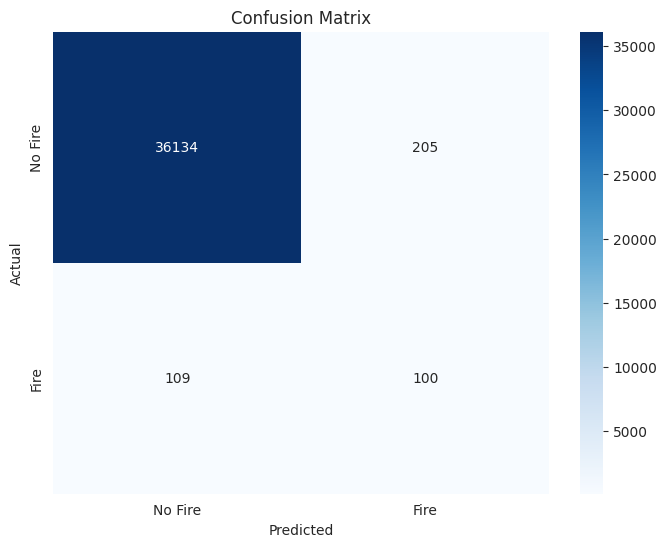

In [26]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print("                 Predicted")
print("                No Fire  |  Fire")
print(f"Actual No Fire  {cm[0,0]:6d}  | {cm[0,1]:6d}")
print(f"       Fire     {cm[1,0]:6d}  | {cm[1,1]:6d}")

print(f"\n📊 Key Metrics:")
print(f"   True Positives (caught fires): {cm[1,1]}")
print(f"   False Negatives (missed fires): {cm[1,0]}")
print(f"   False Positives (false alarms): {cm[0,1]}")
print(f"   True Negatives (correct no-fire): {cm[0,0]}")

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Fire', 'Fire'],
            yticklabels=['No Fire', 'Fire'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

### Precision-Recall Curve


📊 Precision-Recall Metrics:
   AUPRC: 0.3110
   Baseline (random): 0.0057
   Improvement: 54.4x better than random


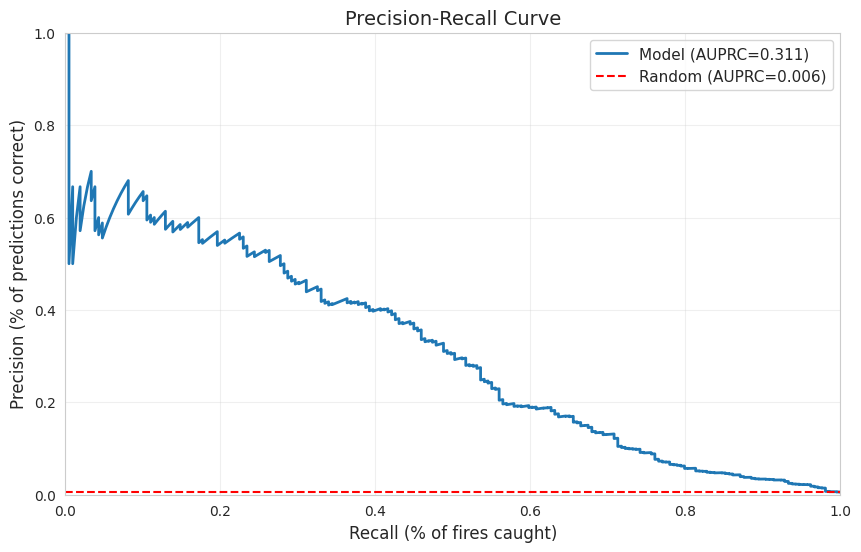


💡 Interpretation:
   Higher AUPRC = better model
   Random baseline = 0.0057 (just predicting fire rate)
   Our model = 0.3110 (54.4x better!)


In [27]:
# Calculate precision and recall at different thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculate AUPRC
auprc = average_precision_score(y_test, y_pred_proba)

# Random baseline (fire rate)
baseline = y_test.mean()

print(f"\n📊 Precision-Recall Metrics:")
print(f"   AUPRC: {auprc:.4f}")
print(f"   Baseline (random): {baseline:.4f}")
print(f"   Improvement: {(auprc/baseline):.1f}x better than random")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label=f'Model (AUPRC={auprc:.3f})', linewidth=2)
plt.axhline(baseline, color='red', linestyle='--', label=f'Random (AUPRC={baseline:.3f})')
plt.xlabel('Recall (% of fires caught)', fontsize=12)
plt.ylabel('Precision (% of predictions correct)', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

print("\n💡 Interpretation:")
print(f"   Higher AUPRC = better model")
print(f"   Random baseline = {baseline:.4f} (just predicting fire rate)")
print(f"   Our model = {auprc:.4f} ({(auprc/baseline):.1f}x better!)")

### Feature Importance


📊 Top 15 Most Important Features:
           feature  importance
       elevation_m         737
         slope_deg         734
        aspect_sin         702
     precip_7d_sum         651
              ndvi         552
        aspect_cos         547
     wind_speed_ms         478
        dewpoint_C         426
         ndvi_lag7         385
         temp_lag7         352
    temp_rolling14         346
       precip_lag3         320
         temp_lag3         308
     temp_rolling7         297
temp_dewpoint_diff         280


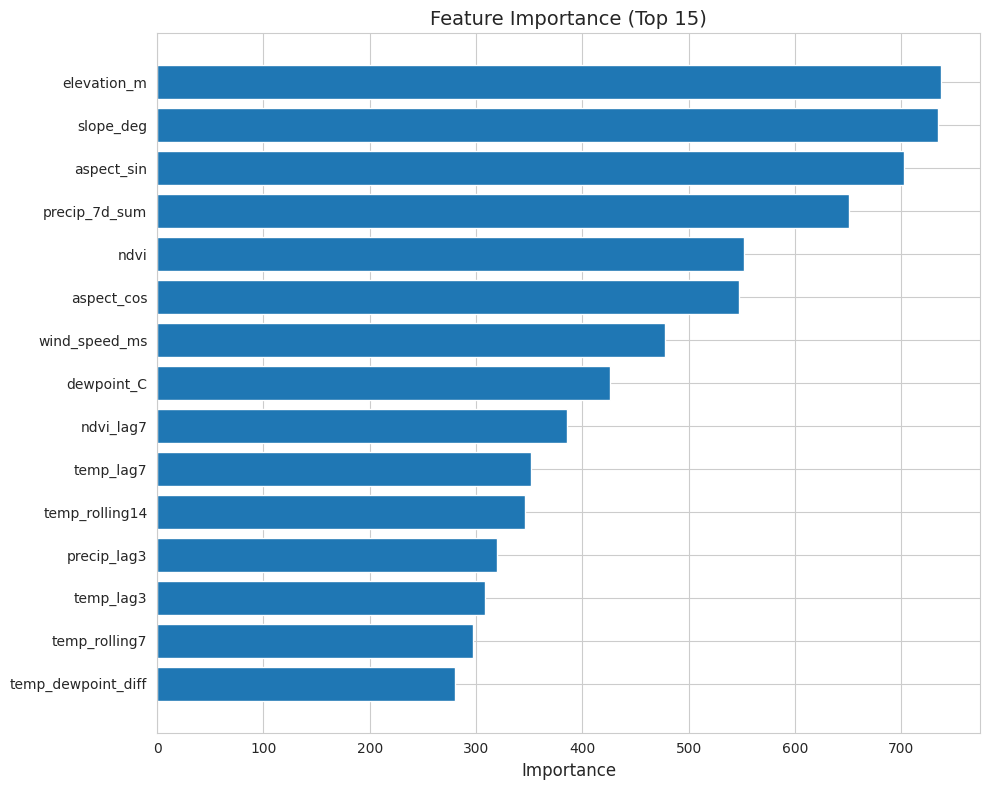

In [28]:
# Get feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance (Top 15)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 🧠 **Expected Top Features**

Based on fire science, you should see:
1. **Temperature** (mean, max, lags) - hot = dry vegetation
2. **Temp-dewpoint diff** - humidity proxy, dryness indicator
3. **Precipitation** (recent history) - wet = lower risk
4. **NDVI** - vegetation fuel availability
5. **Time features** (doy, month) - fire seasonality
6. **Topography** (elevation, slope) - affects fire spread

### Threshold Tuning

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n🎯 Testing different thresholds:\n")

thresholds_to_try = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]

results = []
for thresh in thresholds_to_try:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    
    prec = precision_score(y_test, y_pred_thresh, zero_division=0)
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    
    results.append({
        'threshold': thresh,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    })
    
    print(f"Threshold {thresh:.1f}: Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")

print("\n💡 How to choose:")
print("   • High recall (catch all fires) → Low threshold (0.2-0.3)")
print("   • High precision (avoid false alarms) → High threshold (0.7-0.9)")
print("   • Balanced → F1 score maximized (usually 0.3-0.5)")


🎯 Testing different thresholds:

Threshold 0.1: Precision=0.090, Recall=0.756, F1=0.161
Threshold 0.2: Precision=0.144, Recall=0.679, F1=0.237
Threshold 0.3: Precision=0.192, Recall=0.579, F1=0.289
Threshold 0.5: Precision=0.328, Recall=0.478, F1=0.389
Threshold 0.7: Precision=0.448, Recall=0.311, F1=0.367
Threshold 0.9: Precision=0.636, Recall=0.100, F1=0.174

💡 How to choose:
   • High recall (catch all fires) → Low threshold (0.2-0.3)
   • High precision (avoid false alarms) → High threshold (0.7-0.9)
   • Balanced → F1 score maximized (usually 0.3-0.5)


# **ADDING MORE VISUALS:**
## **BUILDING A DASHBOARD:**


In [31]:
# Extract lat/lon from grid cells
grid_gdf['centroid'] = grid_gdf.geometry.centroid
grid_gdf['lon'] = grid_gdf['centroid'].x
grid_gdf['lat'] = grid_gdf['centroid'].y

# Create lookup
grid_coords = grid_gdf[['cell_id', 'lat', 'lon']].copy()

# Merge with predictions
dashboard_data = features_clean.copy()
dashboard_data['fire_risk'] = model.predict_proba(features_clean[feature_cols])[:, 1]
dashboard_data['actual_fire'] = features_clean['fire_7d_ahead']

# Add lat/lon
dashboard_data = dashboard_data.merge(grid_coords, on='cell_id', how='left')

# Select columns
columns = ['date', 'cell_id', 'lat', 'lon', 'fire_risk', 'actual_fire',
           'elevation_m', 'slope_deg', 'temp_mean_C', 'precip_mm', 
           'ndvi', 'wind_speed_ms', 'dewpoint_C']

export = dashboard_data[[c for c in columns if c in dashboard_data.columns]]
export = export.dropna(subset=['date', 'lat', 'lon', 'fire_risk'])

# Save
export.to_csv('../data/predictions_for_dashboard.csv', index=False)
print(f"✅ Saved {len(export):,} predictions!")

/tmp/ipykernel_7108/4125804712.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  grid_gdf['centroid'] = grid_gdf.geometry.centroid


✅ Saved 155,329 predictions!
